# 11 - Professor Feedback: Forward Validation and Final Evaluation

This notebook closes the main evaluation gaps identified in the project feedback.

It:

1. Defines the flat, zero, and incomplete-day policy **before** training.
2. Uses expanding-window, rolling-origin validation to test future periods.
3. Keeps hourly-consumption evaluation separate from peak-hour evaluation.
4. Compares the selected peak-hour approach with the fixed 14:00 benchmark.
5. Translates the results into a two-hour operational planning window.

The chronological test dataset remains untouched. Only the existing training and validation periods are used here.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
modeling_dir = project_root / "data" / "processed" / "modeling"
reports_dir = project_root / "reports"
figures_dir = project_root / "figures"
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)


## 1. Lock the data-quality policy before training

These rules are based on whether a building-day has enough information to define a unique daily peak. They are not changed after reviewing model performance.

- **Complete variable day:** Keep for primary peak-hour training and evaluation.
- **Complete variable day with some zeros:** Keep. A zero reading can be legitimate when the remaining hours vary.
- **Complete flat nonzero day:** Exclude from the peak target because every hour is tied.
- **Complete flat-zero day:** Exclude from the peak target because no meaningful peak exists.
- **Incomplete day:** Exclude from primary peak evaluation because one or more hours are unavailable.

All records remain in the cleaned dataset. These rules only determine eligibility for the peak-hour target.

In [2]:
quality_policy = pd.DataFrame(
    [
        ["complete_variable", "Include", "24 unique hours and a unique maximum can be identified"],
        ["complete_variable_with_zeros", "Include", "Zeros may be valid when readings still vary"],
        ["complete_flat_nonzero", "Exclude", "All hours are tied, so the peak hour is arbitrary"],
        ["complete_flat_zero", "Exclude", "No electricity-use peak is present"],
        ["incomplete", "Exclude", "Missing hours can hide the true daily peak"],
    ],
    columns=["building_day_category", "peak_model_policy", "reason"],
)
quality_policy.to_csv(reports_dir / "peak_hour_data_quality_policy.csv", index=False)
quality_policy


,building_day_category,peak_model_policy,reason
0,complete_variable,Include,24 unique hours and a unique maximum can be id...
1,complete_variable_with_zeros,Include,Zeros may be valid when readings still vary
2,complete_flat_nonzero,Exclude,"All hours are tied, so the peak hour is arbitrary"
3,complete_flat_zero,Exclude,No electricity-use peak is present
4,incomplete,Exclude,Missing hours can hide the true daily peak


## 2. Build one leakage-safe row per building-day

The target is the hour of maximum electricity consumption. Predictors use building information, weather summaries, calendar information, and the previous consecutive day's consumption profile. No values from the target day's meter readings are used as predictors.

In [3]:
hourly_columns = [
    "building_id", "timestamp", "meter_reading", "site_id", "primary_use",
    "square_feet", "year_built", "air_temperature", "cloud_coverage",
    "dew_temperature", "precip_depth_1_hr", "sea_level_pressure",
    "wind_speed", "hour", "day_of_week", "month", "is_weekend",
]


def build_daily_table(path: Path, source_split: str) -> pd.DataFrame:
    hourly = pd.read_parquet(path, columns=hourly_columns)
    hourly["date"] = hourly["timestamp"].dt.normalize()
    hourly = hourly.sort_values(["building_id", "timestamp"]).reset_index(drop=True)
    grouped = hourly.groupby(["building_id", "date"], observed=True)

    daily = grouped.agg(
        hourly_records=("hour", "count"),
        unique_hours=("hour", "nunique"),
        unique_readings=("meter_reading", "nunique"),
        zero_readings=("meter_reading", lambda values: int((values == 0).sum())),
        daily_mean=("meter_reading", "mean"),
        daily_max=("meter_reading", "max"),
        daily_min=("meter_reading", "min"),
        daily_std=("meter_reading", "std"),
        site_id=("site_id", "first"),
        primary_use=("primary_use", "first"),
        square_feet=("square_feet", "first"),
        year_built=("year_built", "first"),
        day_of_week=("day_of_week", "first"),
        month=("month", "first"),
        is_weekend=("is_weekend", "first"),
        temperature_mean=("air_temperature", "mean"),
        temperature_max=("air_temperature", "max"),
        temperature_min=("air_temperature", "min"),
        dew_temperature_mean=("dew_temperature", "mean"),
        cloud_coverage_mean=("cloud_coverage", "mean"),
        precipitation_total=("precip_depth_1_hr", "sum"),
        sea_level_pressure_mean=("sea_level_pressure", "mean"),
        wind_speed_mean=("wind_speed", "mean"),
        wind_speed_max=("wind_speed", "max"),
    ).reset_index()

    peak_indices = grouped["meter_reading"].idxmax()
    peaks = hourly.loc[
        peak_indices.to_numpy(), ["building_id", "date", "hour"]
    ].rename(columns={"hour": "peak_hour"})

    profile = hourly.pivot_table(
        index=["building_id", "date"], columns="hour",
        values="meter_reading", aggfunc="first",
    ).reindex(columns=range(24))
    profile.columns = [f"reading_h{hour:02d}" for hour in range(24)]
    profile = profile.reset_index()

    daily = daily.merge(peaks, on=["building_id", "date"], validate="one_to_one")
    daily = daily.merge(profile, on=["building_id", "date"], validate="one_to_one")
    daily["source_split"] = source_split
    return daily


train_daily = build_daily_table(modeling_dir / "model_train.parquet", "train")
validation_daily = build_daily_table(
    modeling_dir / "model_validation.parquet", "validation"
)
daily_data = (
    pd.concat([train_daily, validation_daily], ignore_index=True)
    .sort_values(["building_id", "date"])
    .reset_index(drop=True)
)

grouped = daily_data.groupby("building_id", observed=True)
reading_columns = [f"reading_h{hour:02d}" for hour in range(24)]
previous_columns = [
    "daily_mean", "daily_max", "daily_min", "daily_std", "peak_hour",
    "hourly_records",
] + reading_columns

previous_date = grouped["date"].shift(1)
previous_is_consecutive = (
    daily_data["date"] - previous_date
) == pd.Timedelta(days=1)

for column in previous_columns:
    new_column = f"previous_{column}"
    daily_data[new_column] = grouped[column].shift(1)
    daily_data.loc[~previous_is_consecutive, new_column] = np.nan

daily_data["previous_day_complete"] = (
    daily_data["previous_hourly_records"] == 24
).astype("int8")
daily_data["previous_peak_sin"] = np.sin(
    2 * np.pi * daily_data["previous_peak_hour"] / 24
)
daily_data["previous_peak_cos"] = np.cos(
    2 * np.pi * daily_data["previous_peak_hour"] / 24
)
daily_data["log_square_feet"] = np.log1p(daily_data["square_feet"])
daily_data["building_age"] = (2016 - daily_data["year_built"]).clip(lower=0)

daily_data["quality_category"] = np.select(
    [
        (daily_data["hourly_records"] != 24) | (daily_data["unique_hours"] != 24),
        (daily_data["unique_readings"] == 1) & (daily_data["daily_max"] == 0),
        daily_data["unique_readings"] == 1,
        (daily_data["unique_readings"] > 1) & (daily_data["zero_readings"] > 0),
    ],
    [
        "incomplete", "complete_flat_zero", "complete_flat_nonzero",
        "complete_variable_with_zeros",
    ],
    default="complete_variable",
)
daily_data["eligible_target_day"] = daily_data["quality_category"].isin(
    ["complete_variable", "complete_variable_with_zeros"]
)

quality_counts = (
    daily_data["quality_category"].value_counts().rename_axis("quality_category")
    .reset_index(name="building_days")
)
quality_counts["percent"] = quality_counts["building_days"] / len(daily_data) * 100
quality_counts.to_csv(reports_dir / "rolling_origin_quality_counts.csv", index=False)
quality_counts


,quality_category,building_days,percent
0,complete_variable,372075,86.985237
1,complete_flat_nonzero,23851,5.575986
2,complete_flat_zero,17926,4.190815
3,complete_variable_with_zeros,7521,1.758291
4,incomplete,6372,1.489673


## 3. Define expanding-window time folds

Each fold trains on all dates available before its evaluation window. The training window expands forward, while the evaluation period always occurs later in time.

The separate chronological test parquet is not opened in this notebook.

In [4]:
eligible = daily_data[daily_data["eligible_target_day"]].copy()
unique_dates = np.sort(eligible["date"].unique())

fold_boundaries = [
    ("Fold 1", 0.50, 0.65),
    ("Fold 2", 0.65, 0.80),
    ("Fold 3", 0.80, 1.00),
]

folds = []
for fold_name, train_end_fraction, validation_end_fraction in fold_boundaries:
    train_end_index = min(
        int(len(unique_dates) * train_end_fraction), len(unique_dates) - 2
    )
    validation_end_index = min(
        int(len(unique_dates) * validation_end_fraction), len(unique_dates)
    )
    train_end = pd.Timestamp(unique_dates[train_end_index])
    validation_end = pd.Timestamp(unique_dates[validation_end_index - 1])

    fold_train = eligible[eligible["date"] < train_end].copy()
    fold_validation = eligible[
        (eligible["date"] >= train_end)
        & (eligible["date"] <= validation_end)
    ].copy()
    folds.append((fold_name, fold_train, fold_validation))

fold_summary = pd.DataFrame(
    [
        {
            "fold": name,
            "training_start": train["date"].min(),
            "training_end": train["date"].max(),
            "validation_start": validation["date"].min(),
            "validation_end": validation["date"].max(),
            "training_building_days": len(train),
            "validation_building_days": len(validation),
        }
        for name, train, validation in folds
    ]
)
fold_summary.to_csv(reports_dir / "rolling_origin_fold_summary.csv", index=False)
fold_summary


,fold,training_start,training_end,validation_start,validation_end,training_building_days,validation_building_days
0,Fold 1,2016-01-01,2016-06-03,2016-06-04,2016-07-20,179344,60113
1,Fold 2,2016-01-01,2016-07-20,2016-07-21,2016-09-04,239457,59319
2,Fold 3,2016-01-01,2016-09-04,2016-09-05,2016-11-06,298776,80820


## 4. Evaluate the selected peak-hour approach across folds

The evaluation emphasizes three manager-relevant measures:

- **Exact hour:** The predicted peak hour is correct.
- **Within one hour:** The prediction is no more than one hour early or late.
- **Within two hours:** The prediction is no more than two hours early or late.

The fixed 14:00 rule is included in every fold as the practical benchmark.

In [5]:
previous_profile_features = [
    f"previous_reading_h{hour:02d}" for hour in range(24)
]
numeric_features = [
    "log_square_feet", "building_age", "day_of_week", "month", "is_weekend",
    "temperature_mean", "temperature_max", "temperature_min",
    "dew_temperature_mean", "cloud_coverage_mean", "precipitation_total",
    "sea_level_pressure_mean", "wind_speed_mean", "wind_speed_max",
    "previous_daily_mean", "previous_daily_max", "previous_daily_min",
    "previous_daily_std", "previous_peak_sin", "previous_peak_cos",
    "previous_day_complete",
] + previous_profile_features
categorical_features = ["site_id", "primary_use"]
feature_columns = numeric_features + categorical_features


def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(
                        handle_unknown="ignore", sparse_output=True,
                        dtype=np.float32,
                    )),
                ]),
                categorical_features,
            ),
        ],
        sparse_threshold=1.0,
    )


def circular_errors(actual: np.ndarray, predicted: np.ndarray) -> np.ndarray:
    difference = np.abs(actual.astype(int) - predicted.astype(int))
    return np.minimum(difference, 24 - difference)


def metric_row(
    fold: str,
    method: str,
    actual: np.ndarray,
    predicted: np.ndarray,
    fit_seconds: float,
) -> dict:
    errors = circular_errors(actual, predicted)
    return {
        "fold": fold,
        "method": method,
        "evaluated_building_days": len(actual),
        "exact_peak_accuracy": (errors == 0).mean(),
        "within_1_hour_accuracy": (errors <= 1).mean(),
        "within_2_hours_accuracy": (errors <= 2).mean(),
        "mean_peak_hour_error": errors.mean(),
        "median_peak_hour_error": np.median(errors),
        "fit_seconds": fit_seconds,
    }


rolling_rows = []
for fold_name, fold_train, fold_validation in folds:
    print(f"Running {fold_name}...")
    preprocessor = make_preprocessor()
    X_train = preprocessor.fit_transform(
        fold_train[feature_columns]
    ).astype("float32")
    X_validation = preprocessor.transform(
        fold_validation[feature_columns]
    ).astype("float32")
    y_train = fold_train["peak_hour"].to_numpy(dtype="int8")
    y_validation = fold_validation["peak_hour"].to_numpy(dtype="int8")

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=28,
        min_samples_leaf=2,
        max_features="sqrt",
        max_samples=0.35,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    started = perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = perf_counter() - started
    predictions = model.predict(X_validation).astype("int8")

    rolling_rows.append(metric_row(
        fold_name, "Building-specific estimate", y_validation,
        predictions, fit_seconds,
    ))
    rolling_rows.append(metric_row(
        fold_name, "Always predict 14:00", y_validation,
        np.full(len(y_validation), 14, dtype="int8"), 0.0,
    ))

rolling_metrics = pd.DataFrame(rolling_rows)
rolling_metrics.to_csv(
    reports_dir / "rolling_origin_peak_metrics.csv", index=False
)
rolling_metrics


Running Fold 1...
Running Fold 2...
Running Fold 3...


,fold,method,evaluated_building_days,exact_peak_accuracy,within_1_hour_accuracy,within_2_hours_accuracy,mean_peak_hour_error,median_peak_hour_error,fit_seconds
0,Fold 1,Building-specific estimate,60113,0.195981,0.437010,0.597974,2.807296,2.0,296.976448
1,Fold 1,Always predict 14:00,60113,0.104387,0.289089,0.449903,3.748108,3.0,0.000000
2,Fold 2,Building-specific estimate,59319,0.210438,0.457779,0.617896,2.667982,2.0,209.040454
3,Fold 2,Always predict 14:00,59319,0.113421,0.311165,0.471181,3.628096,3.0,0.000000
4,Fold 3,Building-specific estimate,80820,0.203675,0.466060,0.624128,2.657325,2.0,223.091853
5,Fold 3,Always predict 14:00,80820,0.103242,0.291178,0.442205,3.754986,3.0,0.000000


In [6]:
rolling_summary = (
    rolling_metrics.groupby("method", observed=True)
    .agg(
        folds=("fold", "count"),
        exact_hour_mean=("exact_peak_accuracy", "mean"),
        exact_hour_min=("exact_peak_accuracy", "min"),
        exact_hour_max=("exact_peak_accuracy", "max"),
        within_1_hour_mean=("within_1_hour_accuracy", "mean"),
        within_1_hour_min=("within_1_hour_accuracy", "min"),
        within_1_hour_max=("within_1_hour_accuracy", "max"),
        within_2_hours_mean=("within_2_hours_accuracy", "mean"),
        within_2_hours_min=("within_2_hours_accuracy", "min"),
        within_2_hours_max=("within_2_hours_accuracy", "max"),
        mean_hour_error=("mean_peak_hour_error", "mean"),
    )
    .reset_index()
)
rolling_summary.to_csv(
    reports_dir / "rolling_origin_peak_summary.csv", index=False
)
rolling_summary


,method,folds,exact_hour_mean,exact_hour_min,exact_hour_max,within_1_hour_mean,within_1_hour_min,within_1_hour_max,within_2_hours_mean,within_2_hours_min,within_2_hours_max,mean_hour_error
0,Always predict 14:00,3,0.107016,0.103242,0.113421,0.297144,0.289089,0.311165,0.454430,0.442205,0.471181,3.710397
1,Building-specific estimate,3,0.203365,0.195981,0.210438,0.453617,0.437010,0.466060,0.613333,0.597974,0.624128,2.710868


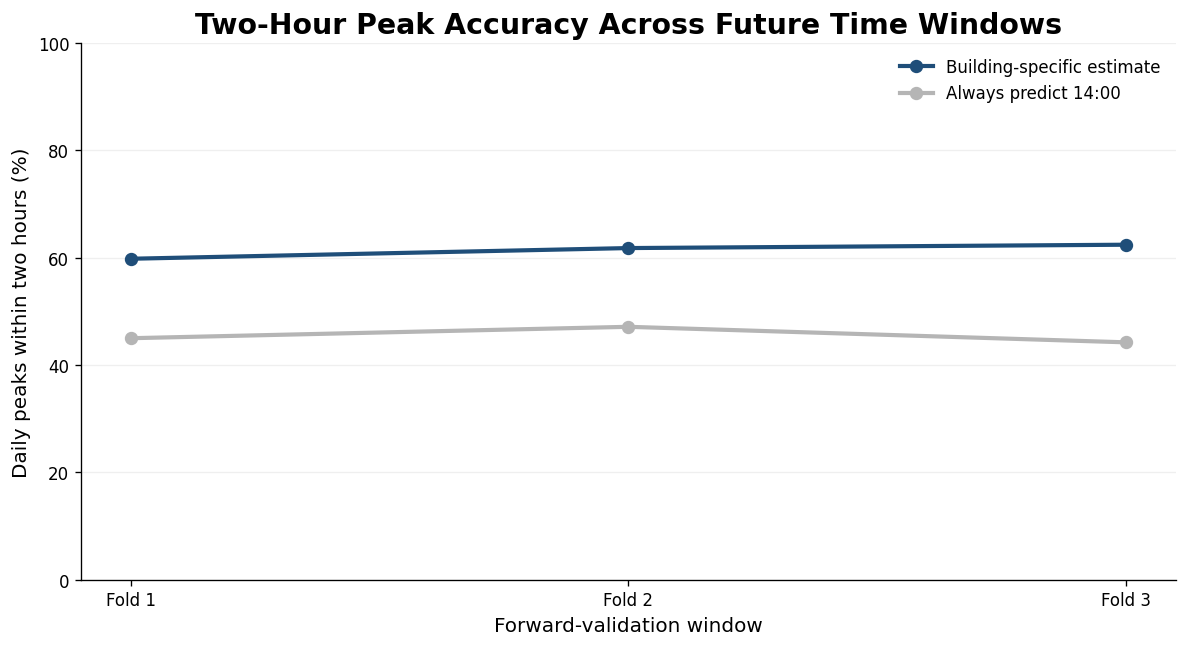

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=120)

plot_data = rolling_metrics.copy()
plot_data["within_2_hours_percent"] = (
    plot_data["within_2_hours_accuracy"] * 100
)

for method, color in [
    ("Building-specific estimate", "#1f4e79"),
    ("Always predict 14:00", "#b5b5b5"),
]:
    method_data = plot_data[plot_data["method"] == method]
    ax.plot(
        method_data["fold"], method_data["within_2_hours_percent"],
        marker="o", linewidth=2.5, markersize=7, color=color, label=method,
    )

ax.set_title("Two-Hour Peak Accuracy Across Future Time Windows", fontsize=17, weight="bold")
ax.set_xlabel("Forward-validation window", fontsize=12)
ax.set_ylabel("Daily peaks within two hours (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
fig.savefig(
    figures_dir / "rolling_origin_two_hour_accuracy.png",
    dpi=150, bbox_inches="tight",
)
plt.show()


## 5. Keep the two prediction tasks separate

Hourly consumption and daily peak timing answer different questions:

- **Hourly-consumption prediction:** How much electricity will be used?
- **Peak-hour prediction:** When will the highest daily demand occur?

A strong consumption score does not automatically mean the peak hour will be correct.

In [8]:
meter_metrics = pd.read_csv(
    reports_dir / "direct_vs_indirect_peak_metrics.csv"
)
hourly_metrics = pd.read_csv(
    reports_dir / "tuned_tabular_validation_metrics.csv"
)

best_hourly = hourly_metrics.loc[
    hourly_metrics["r2"].idxmax()
]
direct_peak = meter_metrics.loc[
    meter_metrics["model"] == "Direct Random Forest Classifier"
].iloc[0]

separate_task_summary = pd.DataFrame([
    {
        "prediction_task": "Hourly electricity consumption",
        "primary_metric": "R-squared",
        "result": best_hourly["r2"],
        "interpretation": "Share of hourly consumption variation explained",
    },
    {
        "prediction_task": "Daily peak timing",
        "primary_metric": "Within two hours",
        "result": direct_peak["within_2_hours_accuracy"],
        "interpretation": "Share of daily peaks identified within a two-hour window",
    },
])
separate_task_summary.to_csv(
    reports_dir / "separate_prediction_task_summary.csv", index=False
)
separate_task_summary


,prediction_task,primary_metric,result,interpretation
0,Hourly electricity consumption,R-squared,0.754937,Share of hourly consumption variation explained
1,Daily peak timing,Within two hours,0.632917,Share of daily peaks identified within a two-h...


## 6. Operational conclusion and limitations

### Recommended use

Use the prediction as a **two-hour readiness window** for scheduling flexible equipment, preparing demand-response actions, and monitoring high-load periods. Do not treat it as a guaranteed exact-hour alarm.

### Important limitations

- Performance can change across seasons and time windows; the rolling results quantify that variation.
- Results are averages across many buildings and may differ for a specific facility.
- Flat, zero, and incomplete days remain available for data-quality monitoring but do not define reliable peak targets.
- Building renovations, new equipment, occupancy changes, and unusual weather can change demand patterns.
- The untouched chronological test period should be used once for the final reported result after the workflow is frozen.